In [ ]:
!pip install kagglehub

import kagglehub # untuk mengunduh dataset kaggle
import random # untuk mengatur keacakan
import tensorflow as tf # untuk membangun, melatih, dan menjalankan arsitektur
import os # untuk berinteraksi dengan os
import matplotlib.pyplot as plt #untuk pengolahan data angka dan matriks
import numpy as np #untuk visualisasi data
from tensorflow.keras import layers # spesifik dari TensorFlow yang menyediakan "blok bangunan"

# 1. Kunci lingkungan OS
os.environ['PYTHONHASHSEED'] = '123'

# 2. Kunci library pengolah angka
random.seed(123)
np.random.seed(123)

# 3. Kunci framework deep learning
tf.random.set_seed(123)

# 4. PAKSA operasi GPU agar urut (Kunci konsistensi total)
tf.config.experimental.enable_op_determinism()

print("Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("techsash/waste-classification-data")
print("✅ Dataset berhasil diunduh ke:", path)

train_dir = os.path.join(path, 'DATASET', 'TRAIN')

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'waste-classification-data' dataset.
✅ Dataset berhasil diunduh ke: /kaggle/input/waste-classification-data


In [ ]:
# --- 1. MEMBACA & MEMBAGI DATASET (80% TRAINING) ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,              # Jalur folder utama dataset sampah
    validation_split=0.2,   # Alokasikan 20% data untuk validasi (uji simulasi)
    subset="training",      # Ambil sisanya (80%) sebagai data latih model
    seed=123,               # Kunci acakan agar pembagian data selalu konsisten
    image_size=(224, 224),  # Ubah ukuran semua gambar menjadi 224x224 piksel
    batch_size=128,         # Model akan membaca 128 gambar sekaligus dalam satu kali komputasi
    label_mode='binary'     # Klasifikasi biner (0 untuk Organik, 1 untuk Anorganik)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,   # Alokasikan 20% data untuk validasi
    subset="validation",    # Ambil porsi 20% tersebut sebagai data uji
    seed=123,
    image_size=(224, 224),
    batch_size=128,
    label_mode='binary'
)

Found 22564 files belonging to 2 classes.
Using 18052 files for training.
Found 22564 files belonging to 2 classes.
Using 4512 files for validation.


In [ ]:
# --- 1. MENYIAPKAN PRE-TRAINED MODEL (MOBILENETV2) ---
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),  # Ukuran input gambar
    include_top=False,          # Buang lapisan klasifikasi asli (ekor model) bawaan ImageNet
    weights='imagenet'          # Gunakan bobot cerdas yang sudah terlatih dari ImageNet
)

# Kunci bobot dasar MobileNetV2 agar tidak berubah selama training (Transfer Learning)
base_model.trainable = False

# --- 2. MENYUSUN STRUKTUR JARINGAN (SEQUENTIAL MODEL) ---
model = tf.keras.Sequential([
    # Lapisan Data Augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2), # Memutar gambar acak maksimal 20%
    layers.RandomZoom(0.2),     # Memperbesar/memperkecil gambar acak 20%
    layers.RandomContrast(0.2), # Mengubah kontras gambar acak 20%

    tf.keras.layers.Rescaling(1./127.5, offset=-1), # Normalisasi piksel ke skala -1 hingga 1
    base_model, # Ekstraktor fitur utama (MobileNetV2)
    tf.keras.layers.GlobalAveragePooling2D(), # Ringkas peta fitur 2D menjadi vektor 1D
    tf.keras.layers.Dense(1, activation='sigmoid') # 1 Neuron + Sigmoid untuk klasifikasi biner
])

# --- 3. KONFIGURASI PROSES BELAJAR (COMPILE MODEL) ---
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 4. REM OTOMATIS TRAINING (CALLBACK EARLY STOPPING) ---
hentikan_otomatis = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', # Pantau pergerakan akurasi
    patience=10, # proses training dihentikan, jika 10 epoch tidak berubah
    restore_best_weights=True #Mengembalikan bobot model ke performa epoch terbaiknya
)

In [ ]:
print("\n🚀 Memulai proses training...")
history = model.fit( # memulai siklus pelatihan neural network
    train_ds, # Mengambil data train
    validation_data=val_ds, # Mengecek performa model di setiap akhir epoch
    epochs=25, # mempelajari seluruh dataset sebanyak maksimal 25 kali pengulangan penuh
    callbacks=[hentikan_otomatis] # rem otomatis Early Stopping
)
print("\n✅ Training Selesai!")


🚀 Memulai proses training...
Epoch 1/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 44s 271ms/step - accuracy: 0.8622 - loss: 0.3222 - val_accuracy: 0.8998 - val_loss: 0.2630
Epoch 2/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 40s 262ms/step - accuracy: 0.9169 - loss: 0.2199 - val_accuracy: 0.9209 - val_loss: 0.2152
Epoch 3/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.9243 - loss: 0.2047 - val_accuracy: 0.9204 - val_loss: 0.2063
Epoch 4/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 41s 264ms/step - accuracy: 0.9243 - loss: 0.1988 - val_accuracy: 0.9291 - val_loss: 0.1935
Epoch 5/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.9284 - loss: 0.1916 - val_accuracy: 0.9286 - val_loss: 0.1886
Epoch 6/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - accuracy: 0.9273 - loss: 0.1907 - val_accuracy: 0.9320 - val_loss: 0.1825
Epoch 7/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - accuracy: 0.9303 - loss: 0.1845 - val_accuracy: 0.9324 - val_loss: 0.1830
Epoch 8/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/ste

In [ ]:
# 1. Menentukan epoch terakhir yang dijalankan
last_epoch = len(history.history['loss'])

# 2. Mengambil nilai metrik di epoch terbaik (setelah restore_best_weights)
# Karena kita menggunakan restore_best_weights=True, kita ambil index akurasi tertinggi
best_epoch_idx = np.argmax(history.history['val_accuracy'])

# mengambil nilai numerik asli dari metrik akurasi dan loss, epoch terbaik lewat best_epoch_idx
final_acc = history.history['accuracy'][best_epoch_idx]
final_loss = history.history['loss'][best_epoch_idx]
final_val_acc = history.history['val_accuracy'][best_epoch_idx]
final_val_loss = history.history['val_loss'][best_epoch_idx]


print("\n" + "="*50)
print("📊 RINGKASAN HASIL TRAINING")
print("="*50)
print(f"✅ Training Berhenti di Epoch  : {last_epoch}")
print(f"🏆 Model Terbaik ditemukan pada: Epoch {best_epoch_idx + 1}")
print("-"*50)
print(f"📈 Akurasi Latih (Training)    : {final_acc*100:.2f}%")
print(f"📉 Loss Latih (Training)       : {final_loss:.4f}")
print(f"🌟 Akurasi Uji (Validation)    : {final_val_acc*100:.2f}%")
print(f"📉 Loss Uji (Validation)       : {final_val_loss:.4f}")
print("="*50)


📊 RINGKASAN HASIL TRAINING
✅ Training Berhenti di Epoch  : 25
🏆 Model Terbaik ditemukan pada: Epoch 25
--------------------------------------------------
📈 Akurasi Latih (Training)    : 93.73%
📉 Loss Latih (Training)       : 0.1677
🌟 Akurasi Uji (Validation)    : 93.88%
📉 Loss Uji (Validation)       : 0.1641


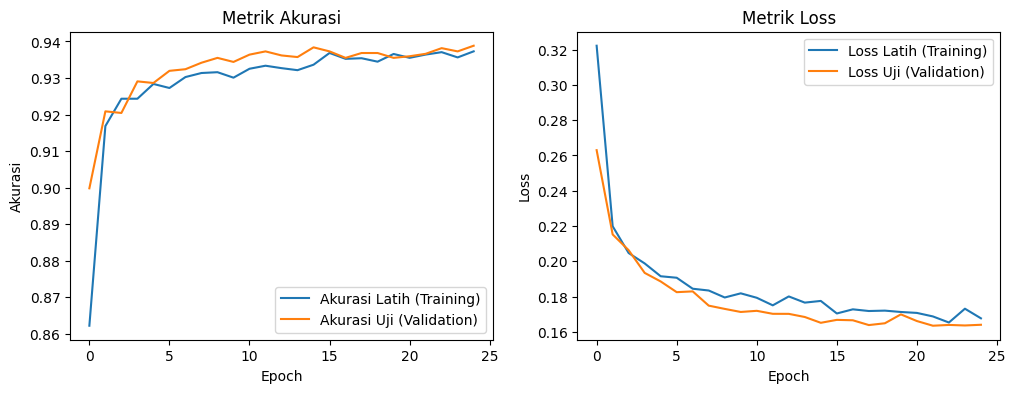

In [ ]:
# Mengambil data dari variabel 'history' yang ada di sel sebelumnya
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Membuat frame gambar
plt.figure(figsize=(12, 4))

# 1. Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(acc, label='Akurasi Latih (Training)')
plt.plot(val_acc, label='Akurasi Uji (Validation)')
plt.title('Metrik Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')

# 2. Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Loss Latih (Training)')
plt.plot(val_loss, label='Loss Uji (Validation)')
plt.title('Metrik Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

🔄 Mengevaluasi model pada data validasi...

📊 LAPORAN KLASIFIKASI:
               precision    recall  f1-score   support

  Organik (O)       0.96      0.93      0.94      2448
Anorganik (R)       0.92      0.95      0.93      2064

     accuracy                           0.94      4512
    macro avg       0.94      0.94      0.94      4512
 weighted avg       0.94      0.94      0.94      4512



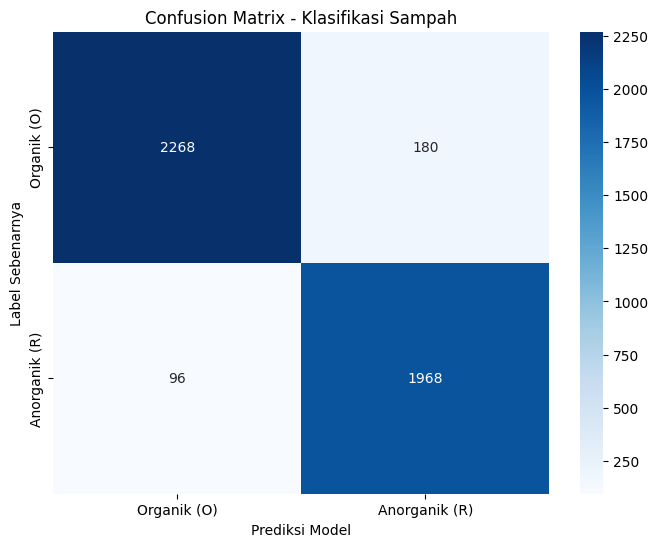

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix #evaluasi performa model
import seaborn as sns #untuk visualisasi data statistik
import matplotlib.pyplot as plt

print("🔄 Mengevaluasi model pada data validasi...")

# 1. Mengumpulkan label asli (y_true) dan prediksi (y_pred) secara sejajar
y_true = []
y_pred = []

# Iterasi langsung melalui val_ds untuk memastikan urutan gambar dan label cocok
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Menampilkan Laporan Klasifikasi (Precision, Recall, F1-Score)
target_names = ['Organik (O)', 'Anorganik (R)']
print("\n📊 LAPORAN KLASIFIKASI:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Membuat dan Menampilkan Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Klasifikasi Sampah')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

In [ ]:
def tebak_sampah(image_path):
    try:
        # 1. Load gambar dan ubah ukurannya menjadi 224x224 piksel sesuai input model
        img = tf.keras.utils.load_img(image_path, target_size=(224, 224))

        # 2. Konversi gambar jadi array angka dan tambah dimensi batch (dari [224,224,3] jadi [1,224,224,3])
        img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)

        # 3. Lakukan prediksi menggunakan model (verbose=0 agar prosesnya tidak memunculkan log loading)
        score = model.predict(img_array, verbose=0)[0][0]

        print("\n" + "="*45)
        if score > 0.5:
            print(f"♻️  PREDIKSI: (R) Recyclable / Anorganik\n📊  Keyakinan: {score * 100:.2f}%")
        else:
            print(f"🍂  PREDIKSI: (O) Organic / Organik\n📊  Keyakinan: {(1 - score) * 100:.2f}%")
        print("="*45 + "\n")
    except Exception as e:
        print(f"❌ ERROR: Tidak dapat membaca gambar. Detail: {e}")

In [ ]:
from google.colab import files

# Memunculkan tombol upload
uploaded = files.upload()

for filename in uploaded.keys():
    # File otomatis tersimpan di folder '/content/' dengan nama aslinya
    print(f'Mengolah gambar: {filename}')
    tebak_sampah(filename)

Saving sampah.jpg to sampah.jpg
Mengolah gambar: sampah.jpg

🍂  PREDIKSI: (O) Organic / Organik
📊  Keyakinan: 98.28%



In [ ]:
# Memunculkan tombol upload
uploaded = files.upload()

for filename in uploaded.keys():
    # File otomatis tersimpan di folder '/content/' dengan nama aslinya
    print(f'Mengolah gambar: {filename}')
    tebak_sampah(filename)

Saving gambarsampah.jpg to gambarsampah.jpg
Mengolah gambar: gambarsampah.jpg

♻️  PREDIKSI: (R) Recyclable / Anorganik
📊  Keyakinan: 92.90%



In [ ]:
# Memunculkan tombol upload
uploaded = files.upload()

for filename in uploaded.keys():
    # File otomatis tersimpan di folder '/content/' dengan nama aslinya
    print(f'Mengolah gambar: {filename}')
    tebak_sampah(filename)

Saving images (2).jpg to images (2).jpg
Mengolah gambar: images (2).jpg

♻️  PREDIKSI: (R) Recyclable / Anorganik
📊  Keyakinan: 91.88%



In [ ]:
# Memunculkan tombol upload
uploaded = files.upload()

for filename in uploaded.keys():
    # File otomatis tersimpan di folder '/content/' dengan nama aslinya
    print(f'Mengolah gambar: {filename}')
    tebak_sampah(filename)

Saving Composting-NYC-1024x756-1.jpg to Composting-NYC-1024x756-1.jpg
Mengolah gambar: Composting-NYC-1024x756-1.jpg

🍂  PREDIKSI: (O) Organic / Organik
📊  Keyakinan: 99.69%

